# Initial Data Analysis

In [1]:
import matplotlib.pyplot as plt

from bioacoustics.data import load_metadata
from bioacoustics.preprocessing import get_labels

from bioacoustics.visualization import (
    plot_label_frequency,
    plot_active_labels,
    plot_label_concurrence,
)

%load_ext autoreload
%autoreload 2

## Load metadata and get labels

In [174]:
df_train, df_train_soundscapes, df_taxonomy = load_metadata()
y_class, y_primary = get_labels(df_train, df_taxonomy)
y_class_soundscapes, y_primary_soundscapes = get_labels(df_train_soundscapes, df_taxonomy)

## Stats on metadata

<div style="color:red"> TODO: explore the metadata features, think how to integrate them </div>

For now I am going to ignore the secondary labels as they concern only a small fraction of the data.

In [166]:
print(
    f"Percentage of train audio with secondary labels: {(df_train['secondary_labels'] != '[]').sum() / len(df_train) * 100:.2f}%"
)

Percentage of train audio with secondary labels: 12.30%


There are very many different types of calls, songs, etc... It would likely make sense combine them into different categories e.g. songs, calls, etc so that there can be clearer similarities between the calories. I've listed them here.

In [167]:
import ast

possible_types = {
    t
    for lst in df_train["type"].unique()
    for t in ast.literal_eval(lst)
}

print(possible_types)

{'', ' calls (alarm?)', ' gutural sound', ' "chick-burrrr" call.', ' a harsh noisy call with pitch range 1-12 kHz lasting', ' pheugopedius mystacalis', ' pb', ' calls by presumed pair', ' lekk song', ' nyctibeus griseus', 'chamdo', ' complete song maybe missing the first note.', ' ?', ' dusk song', ' Musical calls', " 'purweer' song", ' pouso em galhos', ' Complex song', ' night flight call', ' rolling call', ' perched', ' dry gravelly calls.', 'aberrant call', ' a low machine like sound between the crackles', 'individuo criado en laboratorio. sonido al momento de ser alimentado.', ' songs a and b and calls', ' "', ' chouic', ' anxiety call', 'calling in flight', ' donkey vocalizing.', ' call/song', ' excited calls', ' (alarm) calls. song.', ' moorning song', 'growl', 'não sei', ' daytime duet', ' excited call', 'camptostoma obsoletum', ' 4-noted song', ' song 2', ' contact call', ' soft calls between a pair', ' alarm call', ' different song type', ' subsong', ' two different calls', '

## Stats on labels

In [168]:
print(f"Number of Classes: {df_taxonomy["class_name"].nunique()}")
print(f"Number of Species: {df_taxonomy["primary_label"].nunique()}")

Number of Classes: 5
Number of Species: 234


### Train data

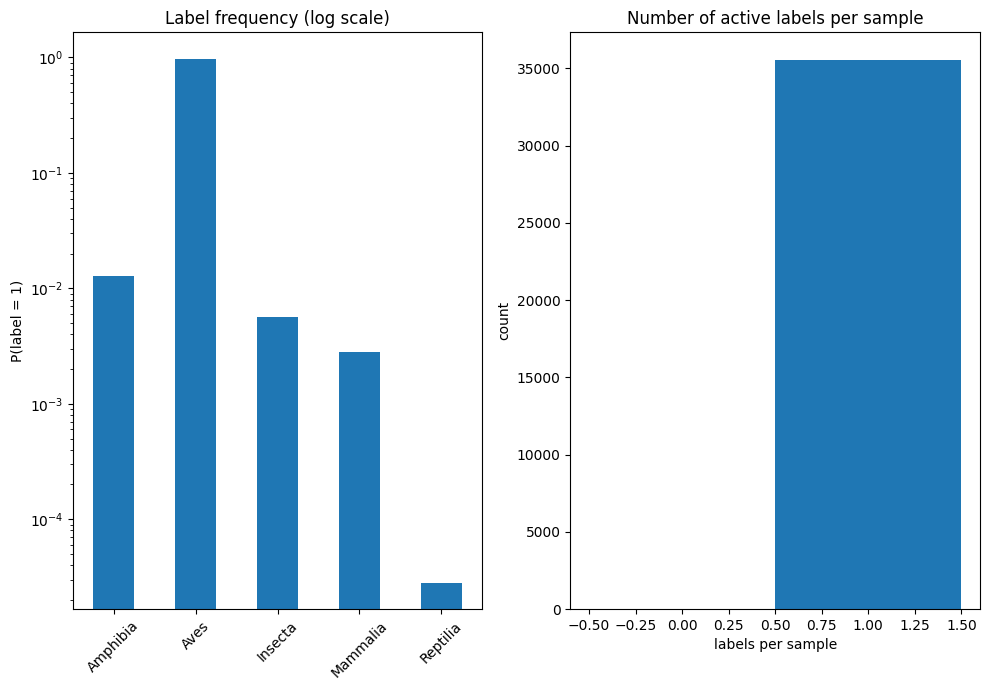

In [169]:
fig, axes = plt.subplots(1,2, figsize=(10,7))
plot_label_frequency(y_class, ax=axes[0])
plot_active_labels(y_class, ax=axes[1])
plt.tight_layout()
plt.show()

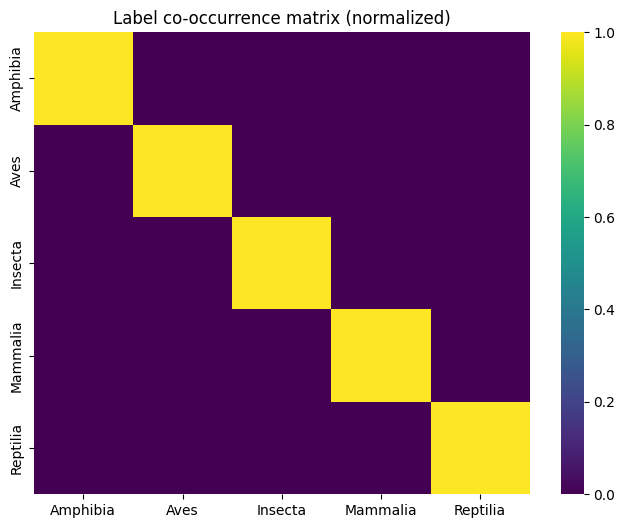

In [170]:
plot_label_concurrence(y_class)

### Train soundscapes

Resemble the test data.

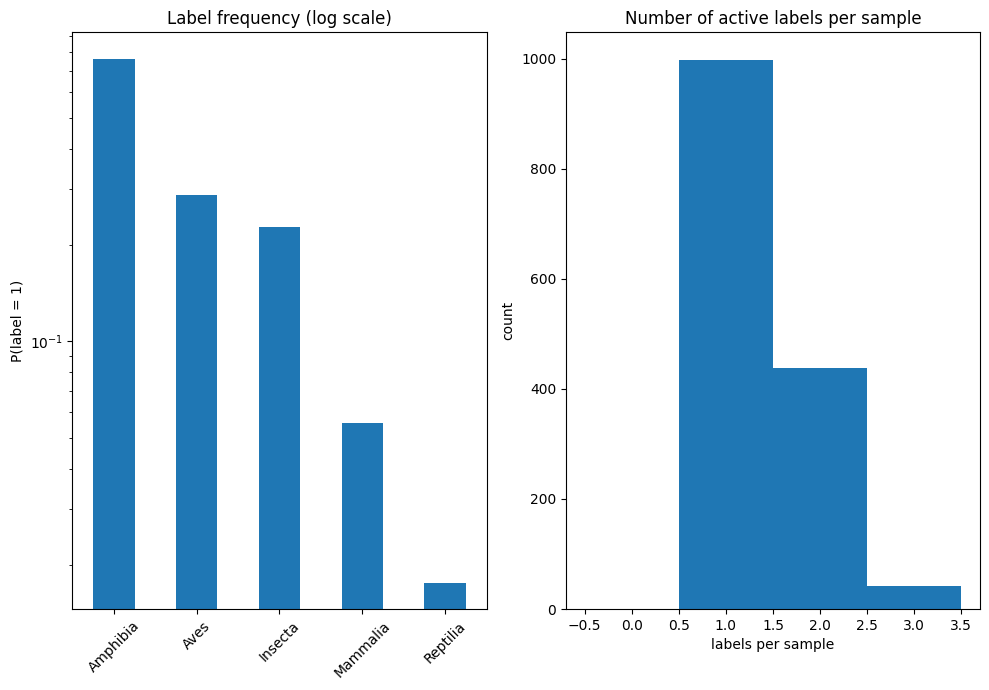

In [171]:
fig, axes = plt.subplots(1, 2, figsize=(10, 7))
plot_label_frequency(y_class_soundscapes, ax=axes[0])
plot_active_labels(y_class_soundscapes, ax=axes[1])
plt.tight_layout()
plt.show()

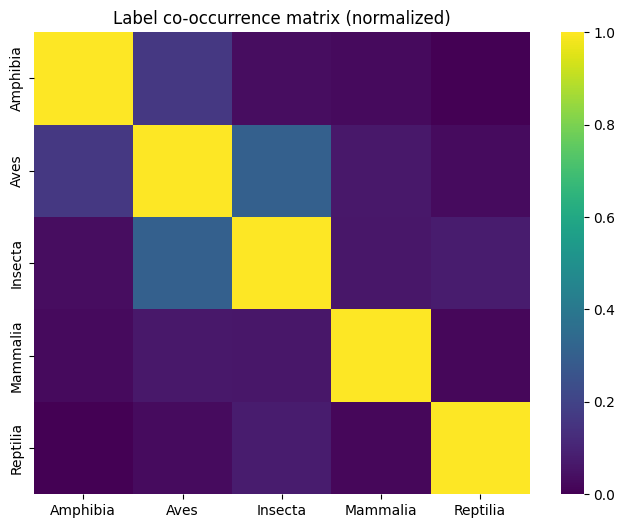

In [172]:
plot_label_concurrence(y_class_soundscapes)